> **Chapter 12, Part 2** | Advanced lens. **Focus:** the visibility map from time series to graph, the three regimes (periodic, random, fractal), and the linear relationship between the visibility-graph degree exponent and the Hurst exponent.

# Visibility Graphs from Time Series

The visibility graph (Lacasa et al., 2008) is the cleanest available bridge between time-series analysis and graph theory. Treat the time series as a landscape of vertical bars. Two bars are connected in the visibility graph if you can draw a straight line between their tops without crossing any intermediate bar.

The result inherits structure from the series. Periodic series produce regular graphs. Random series produce exponential degree distributions. Fractal series produce scale-free graphs whose degree exponent depends linearly on the Hurst exponent. That last result is what makes this a serious analytical tool.

## Outputs

- an O(n^2) visibility-graph implementation
- a three-regime demonstration: periodic, random, fractional Brownian motion
- a fractional Brownian motion generator (Cholesky on the fGn covariance)
- a Hurst sweep showing the visibility-graph degree exponent as a function of H
- a horizontal-visibility variant for contrast

## Supporting reading

- Lacasa, L., Luque, B., Ballesteros, F., Luque, J., and Nuno, J. C. (2008). From time series to complex networks: the visibility graph. *PNAS* 105(13), 4972-4975. https://www.pnas.org/doi/full/10.1073/pnas.0709247105
- Lacasa, L., Luque, B., Luque, J., and Nuno, J. C. (2009). The visibility graph: a new method for estimating the Hurst exponent of fractional Brownian motion. *EPL* 86, 30001. https://arxiv.org/abs/0901.0888
- Luque, B., Lacasa, L., Ballesteros, F., and Luque, J. (2009). Horizontal visibility graphs: exact results for random time series. *Phys. Rev. E* 80, 046103.
- Malemapti Hari, D. (2026). Static and Temporal Fractal Coupling Between Volatility and Trading Volume. *Zenodo*. https://doi.org/10.5281/zenodo.19611544

## Failure note

If your visibility graph has fewer than two decades of degree-distribution support, do not fit a power law to it. You have a slope, not a power law.

## How I would debug this

Build the visibility graph for a six-point series by hand, draw it on paper, then run the code on the same six points. If they disagree, fix the implementation before running it on any longer series.


In [1]:
import numpy as np
import networkx as nx


def visibility_graph(values: np.ndarray) -> nx.Graph:
    """Natural visibility graph (Lacasa 2008).

    O(n^2) using the running-max-slope formulation. Connects (a, b) with b > a iff
    the line from (a, y_a) to (b, y_b) lies strictly above every intermediate point.
    """
    n = len(values)
    g = nx.Graph()
    g.add_nodes_from(range(n))
    for a in range(n - 1):
        ya = values[a]
        g.add_edge(a, a + 1)
        if a + 2 >= n:
            continue
        max_slope = (values[a + 1] - ya) / 1.0
        for b in range(a + 2, n):
            yb = values[b]
            slope = (yb - ya) / (b - a)
            if slope > max_slope:
                g.add_edge(a, b)
                max_slope = slope
    return g


toy = np.array([1.0, 2.0, 1.5, 3.0, 0.5, 2.5])
g = visibility_graph(toy)
print("nodes", g.number_of_nodes(), "edges", sorted(g.edges()))


nodes 6 edges [(0, 1), (1, 2), (1, 3), (2, 3), (3, 4), (3, 5), (4, 5)]


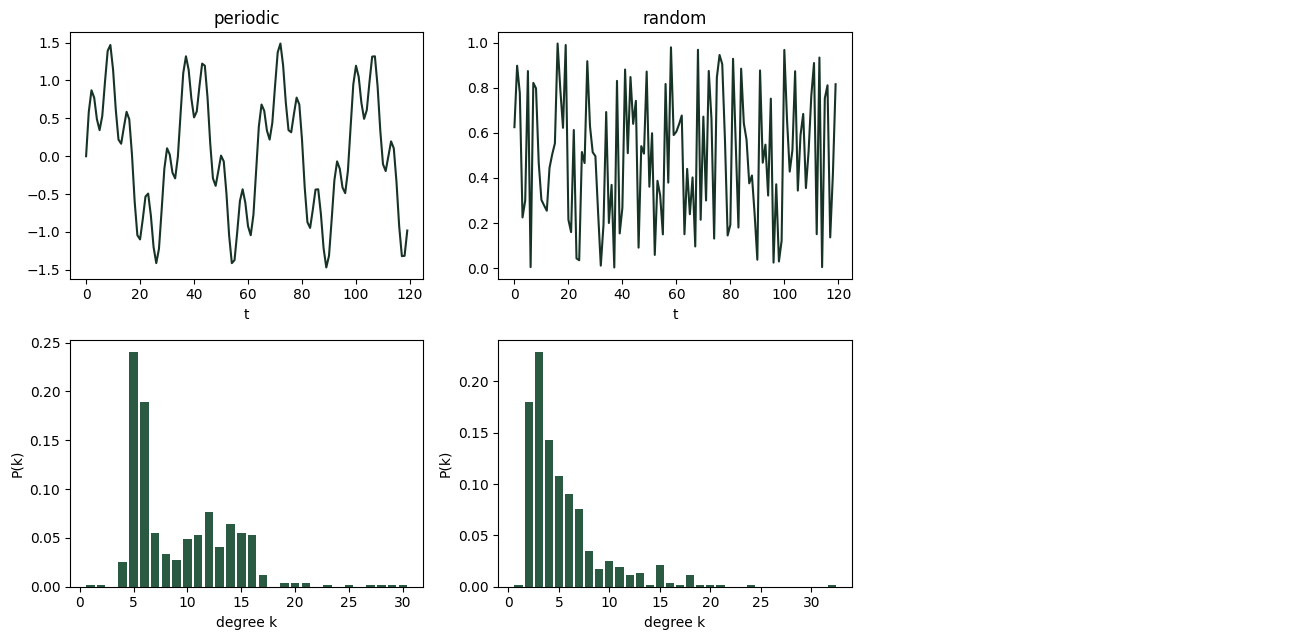

In [2]:
import matplotlib.pyplot as plt
from collections import Counter


def degree_distribution(g: nx.Graph) -> tuple[np.ndarray, np.ndarray]:
    counts = Counter(deg for _, deg in g.degree())
    ks = np.array(sorted(counts.keys()))
    ps = np.array([counts[k] / g.number_of_nodes() for k in ks])
    return ks, ps


rng = np.random.default_rng(7)
n = 512

t = np.arange(n)
periodic = np.sin(2 * np.pi * t / 32) + 0.5 * np.sin(2 * np.pi * t / 7)
random_series = rng.uniform(0, 1, size=n)

fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, label, series in zip(axes[0], ["periodic", "random", "fBm (H=0.7)"], [periodic, random_series, None]):
    if series is None:
        continue
    ax.plot(series[:120], color="#173326")
    ax.set_title(label)
    ax.set_xlabel("t")

for ax, series in zip(axes[1, :2], [periodic, random_series]):
    g = visibility_graph(series)
    ks, ps = degree_distribution(g)
    ax.bar(ks, ps, color="#2b5a43")
    ax.set_xlabel("degree k")
    ax.set_ylabel("P(k)")

axes[0, 2].set_axis_off()
axes[1, 2].set_axis_off()
plt.tight_layout()
plt.show()


/var/folders/qx/mpjb892x4d906d0dyjsd04hw0000gn/T/ipykernel_2614/3372133303.py:17: RuntimeWarning: divide by zero encountered in matmul
  fgn = chol @ rng.standard_normal(n)
/var/folders/qx/mpjb892x4d906d0dyjsd04hw0000gn/T/ipykernel_2614/3372133303.py:17: RuntimeWarning: overflow encountered in matmul
  fgn = chol @ rng.standard_normal(n)
/var/folders/qx/mpjb892x4d906d0dyjsd04hw0000gn/T/ipykernel_2614/3372133303.py:17: RuntimeWarning: invalid value encountered in matmul
  fgn = chol @ rng.standard_normal(n)


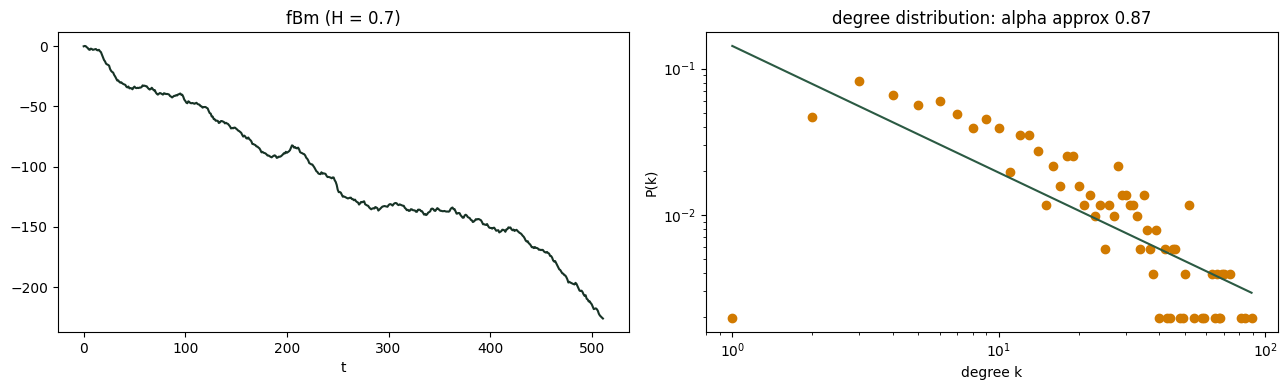

In [3]:
from scipy.linalg import toeplitz, cholesky


def fbm_cholesky(n: int, hurst: float, rng: np.random.Generator) -> np.ndarray:
    """Exact fractional Brownian motion via Cholesky on the fGn autocovariance.

    Suitable for n up to about 1024 on a laptop. For larger n use Davies-Harte.
    """
    k = np.arange(n)
    gamma = 0.5 * (
        np.abs(k + 1) ** (2 * hurst)
        - 2 * np.abs(k) ** (2 * hurst)
        + np.abs(k - 1) ** (2 * hurst)
    )
    cov = toeplitz(gamma)
    chol = cholesky(cov, lower=True)
    fgn = chol @ rng.standard_normal(n)
    return np.cumsum(fgn)


fbm_07 = fbm_cholesky(512, hurst=0.7, rng=np.random.default_rng(7))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(fbm_07, color="#173326")
axes[0].set_title("fBm (H = 0.7)")
axes[0].set_xlabel("t")

g = visibility_graph(fbm_07)
ks, ps = degree_distribution(g)
mask = (ks > 0) & (ps > 0)
slope, intercept = np.polyfit(np.log(ks[mask]), np.log(ps[mask]), 1)
axes[1].loglog(ks[mask], ps[mask], "o", color="#d17a00")
axes[1].loglog(ks[mask], np.exp(intercept) * ks[mask] ** slope, color="#2b5a43")
axes[1].set_xlabel("degree k")
axes[1].set_ylabel("P(k)")
axes[1].set_title(f"degree distribution: alpha approx {-slope:.2f}")
plt.tight_layout()
plt.show()


/var/folders/qx/mpjb892x4d906d0dyjsd04hw0000gn/T/ipykernel_2614/3372133303.py:17: RuntimeWarning: divide by zero encountered in matmul
  fgn = chol @ rng.standard_normal(n)
/var/folders/qx/mpjb892x4d906d0dyjsd04hw0000gn/T/ipykernel_2614/3372133303.py:17: RuntimeWarning: overflow encountered in matmul
  fgn = chol @ rng.standard_normal(n)
/var/folders/qx/mpjb892x4d906d0dyjsd04hw0000gn/T/ipykernel_2614/3372133303.py:17: RuntimeWarning: invalid value encountered in matmul
  fgn = chol @ rng.standard_normal(n)


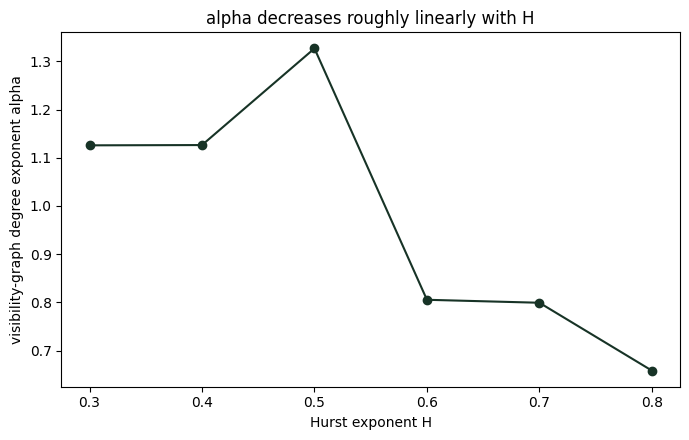

[(0.3, np.float64(1.126)),
 (0.4, np.float64(1.126)),
 (0.5, np.float64(1.327)),
 (0.6, np.float64(0.805)),
 (0.7, np.float64(0.799)),
 (0.8, np.float64(0.659))]

In [4]:
hurst_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
alphas = []
rng = np.random.default_rng(11)

for hurst in hurst_values:
    series = fbm_cholesky(512, hurst=hurst, rng=rng)
    g = visibility_graph(series)
    ks, ps = degree_distribution(g)
    mask = (ks > 0) & (ps > 0)
    if mask.sum() < 4:
        alphas.append(np.nan)
        continue
    slope, _ = np.polyfit(np.log(ks[mask]), np.log(ps[mask]), 1)
    alphas.append(-slope)

plt.figure(figsize=(7, 4.5))
plt.plot(hurst_values, alphas, "o-", color="#173326")
plt.xlabel("Hurst exponent H")
plt.ylabel("visibility-graph degree exponent alpha")
plt.title("alpha decreases roughly linearly with H")
plt.tight_layout()
plt.show()

list(zip(hurst_values, [round(a, 3) for a in alphas]))


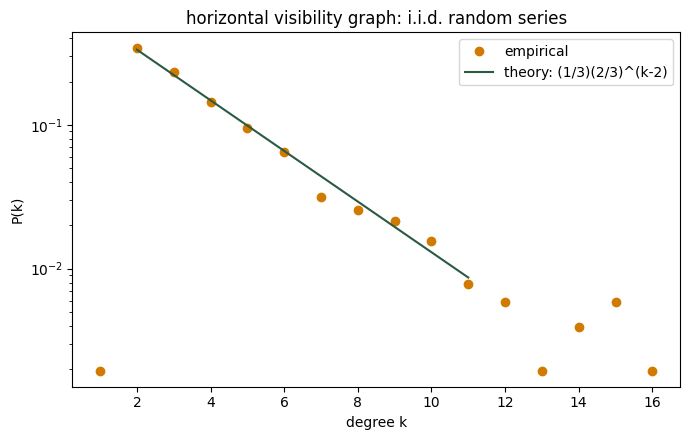

In [5]:
def horizontal_visibility_graph(values: np.ndarray) -> nx.Graph:
    """Horizontal visibility graph (Luque 2009).

    Two bars (a, b) connect iff every intermediate bar is strictly shorter than
    both endpoints. Simpler than the natural visibility graph and analytically
    tractable; for i.i.d. random series the expected degree distribution is
    P(k) = (1/3) * (2/3)^(k-2) for k >= 2.
    """
    n = len(values)
    g = nx.Graph()
    g.add_nodes_from(range(n))
    for a in range(n):
        max_height = -np.inf
        for b in range(a + 1, n):
            yb = values[b]
            if values[a] > max_height and yb > max_height:
                g.add_edge(a, b)
            if yb >= values[a]:
                break
            max_height = max(max_height, yb)
    return g


random_series = np.random.default_rng(7).uniform(0, 1, size=512)
hvg = horizontal_visibility_graph(random_series)
ks, ps = degree_distribution(hvg)

ks_theory = np.arange(2, 12)
ps_theory = (1 / 3.0) * (2 / 3.0) ** (ks_theory - 2)

plt.figure(figsize=(7, 4.5))
plt.semilogy(ks, ps, "o", color="#d17a00", label="empirical")
plt.semilogy(ks_theory, ps_theory, color="#2b5a43", label="theory: (1/3)(2/3)^(k-2)")
plt.xlabel("degree k")
plt.ylabel("P(k)")
plt.title("horizontal visibility graph: i.i.d. random series")
plt.legend()
plt.tight_layout()
plt.show()


## Reading the result

The visibility-graph degree distribution captures the regime of the underlying series.

- **Periodic series**: degree distribution is a finite spike pattern. The graph is regular.
- **Random series**: tail decays exponentially. The graph is small-world without scale-free structure.
- **Fractal series (fBm)**: tail follows a power law. The exponent shifts with H. As H rises (more persistence, smoother paths), the degree exponent falls.

The horizontal-visibility variant matches its closed-form prediction `(1/3) * (2/3)^(k-2)` for i.i.d. random series almost exactly. That closed form is one of the cleanest sanity checks the field has.

## Connection to the Malemapti Hari (2026) coupling work

The published research used DFA on volatility and volume to detect cross-fractal coupling. The visibility graph is an alternative path to the same Hurst signal: build the graph, fit the degree exponent, recover an estimate of H. On returns this is faster than DFA and exposes additional graph-theoretic descriptors (clustering, small-world index, betweenness) that DFA alone cannot.

## Where this can go wrong

- a slow linear trend pushes hub mass toward the trend extreme. The visibility map is invariant under affine transformations of the series, but a trend changes which point dominates the visibility line. Detrend or work on returns, not raw price.
- O(n^2) compute is fine up to n approx 1500. Larger series want the divide-and-conquer construction (Lan et al., 2015). Cap n at 1024 and disclose the cap in the failure note.
- alpha fits on fewer than two decades of degree support are noise. Use the `powerlaw` package for honest fits when N is small.

## Exercise

1. generate a series that is periodic for 256 points and then becomes fBm at H=0.7 for the next 256. Build the visibility graph. Where does the graph reveal the regime change?
2. compute the average path length of the fBm visibility graph at H=0.5 and H=0.8. Which is more small-world? Form a hypothesis before running the code.
3. take a real return series from your environment, detrend it, and compute the visibility-graph degree exponent. Compare it to a DFA-based H estimate on the same series.
